# Exercise 1: K-Means Clustering on Old Faithful Geyser Data

Implement K-Means clustering on Geyser's Eruptions Segmentation to segregate waiting time between eruptions and the duration of the eruption for the Old Faithful geyser.

In [1]:
# CH.SC.U4CSE24119 Kavin JS

import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

## Load Dataset

In [2]:
data = pd.read_csv('../Data/geyser.csv')
print(data.shape)
data.head()

(272, 3)


,duration,waiting,kind
0,3.600,79,long
1,1.800,54,short
2,3.333,74,long
3,2.283,62,short
4,4.533,85,long


## Select Features (waiting time and duration)

In [3]:
x = data[['waiting', 'duration']].values
print(f'Shape: {x.shape}')

Shape: (272, 2)


## Elbow Method

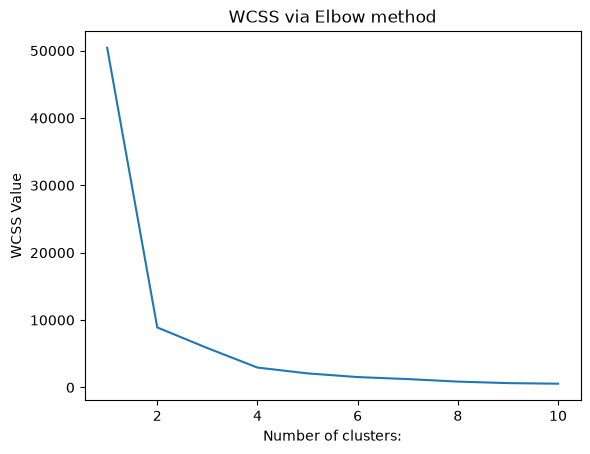

In [4]:
wcss = []
for i in range(1, 11):
    model = KMeans(n_clusters=i, init='k-means++', random_state=21)
    model.fit(x)
    wcss.append(model.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('WCSS via Elbow method')
plt.xlabel('Number of clusters:')
plt.ylabel('WCSS Value')
plt.show()

## K-Means Clustering

In [5]:
# From the elbow plot, k=2 or k=3 are reasonable choices
model = KMeans(n_clusters=2, init='k-means++', random_state=42)
y_means = model.fit_predict(x)
print("Cluster labels:", np.unique(y_means))
print("Cluster centers:\n", model.cluster_centers_)

Cluster labels: [0 1]
Cluster centers:
 [[80.28488372  4.29793023]
 [54.75        2.09433   ]]


## Visualize the Clusters

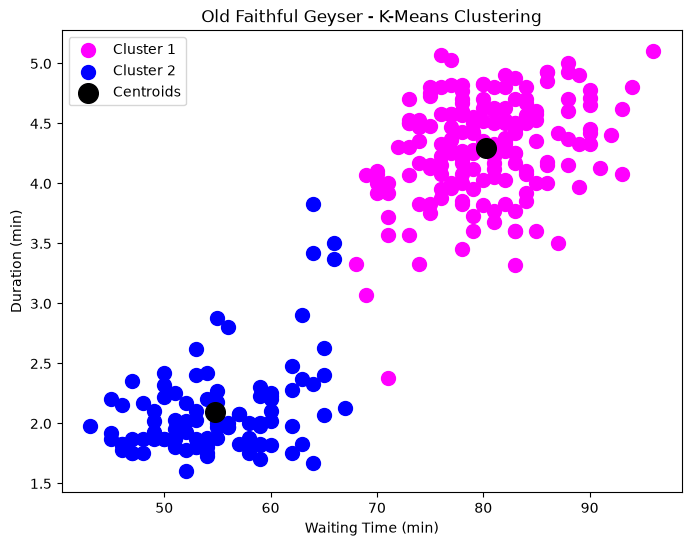

In [6]:
plt.figure(figsize=(8, 6))
colors = ['magenta', 'blue', 'orange']
for i in range(model.n_clusters):
    plt.scatter(x[y_means==i, 0], x[y_means==i, 1], s=100, c=colors[i % len(colors)], label=f'Cluster {i+1}')
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], s=200, c='black', label='Centroids')
plt.title('Old Faithful Geyser - K-Means Clustering')
plt.xlabel('Waiting Time (min)')
plt.ylabel('Duration (min)')
plt.legend()
plt.show()

## Analysis

The clustering reveals two distinct eruption patterns: short-duration eruptions with shorter waiting times, and long-duration eruptions with longer waiting times. This is consistent with the known bimodal behavior of Old Faithful.